In [313]:
# save pdf figures so that text is editable in AI
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

### Load in cell-by-gene matrix

In [707]:
import pandas as pd
import numpy as np

# load cell-by-gene matrix
enhancer_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_enhancers_cbg_clean_drift_corrected.csv')
T7_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_transcripts_cbg_clean_drift_corrected.csv')
old_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\cell_by_CRE_10_12_2023.csv')
# norm_cbg = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_normalized_cbg.csv')
# log2_FC = pd.read_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_log2_FC_cbg.csv')

### Check the detection frequency of each enhancer/T7 transcript across all cells

In [482]:
cre_presence = []

for cre in T7_cbg.columns[1:21]:
    present = T7_cbg[cre] > 0
    present_ = present.sum()
    present__ = present_/len(T7_cbg)
    cre_presence.append(present__)

cre_presence.insert(0, 'percent detected')
cre_names = [cre for cre in T7_cbg.columns[:21]]
cbg = T7_cbg.filter(cre_names, axis=1)
cbg.loc[cbg.index.max() + 1, :] = cre_presence

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_40032\3369258976.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'percent detected' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cbg.loc[cbg.index.max() + 1, :] = cre_presence


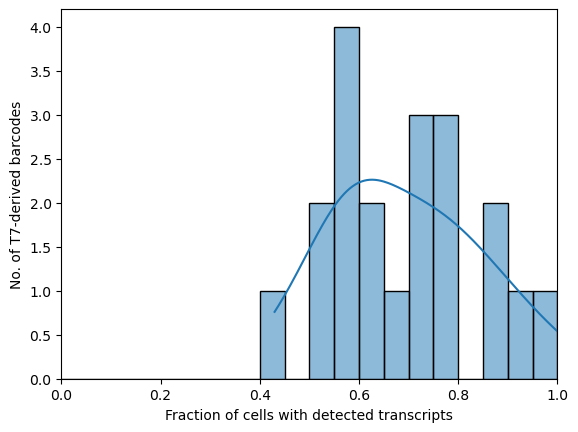

In [483]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax = sns.histplot(x=cbg.iloc[-1,1:21], binwidth=0.05, binrange=(0,1), legend=False, kde=True)
ax.set_xlim(0,1)
ax.set_xlabel('Fraction of cells with detected transcripts')
ax.set_ylabel('No. of T7-derived barcodes')
# ax.set_title('T7 transcripts')
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_detection_stats_240816.pdf')

([], [])

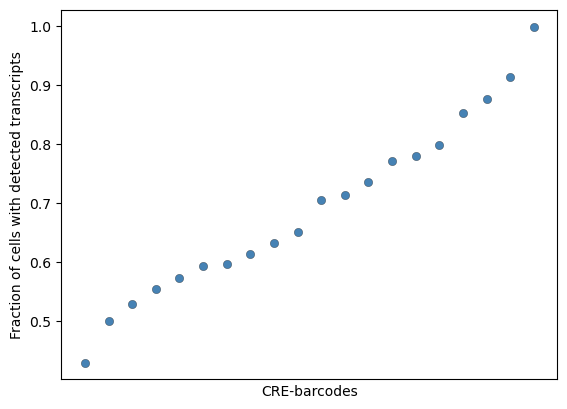

In [484]:
fig, ax = plt.subplots()
ax = sns.scatterplot(x=range(0,20),y=np.sort(cbg.iloc[-1,1:21]), facecolor='steelblue', edgecolor='k', lw=0.2)
ax.set_xlim(-1,20)
ax.set_xlabel('CRE-barcodes')
ax.set_ylabel('Fraction of cells with detected transcripts')
plt.xticks([])
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/fraction_of_cells_transcript_detected_scatterplot_240504', dpi=450)

### Actually normalize the enhancer counts by T7 counts

In [708]:
# merge the enhancer and T7 counts
merged = pd.merge(enhancer_cbg, T7_cbg, how='left', left_on='masks', right_on='masks')

In [709]:
# divide enhancer counts by T7 counts in merged cbg matrix
for cre in CREs:
    idx = str(cre + '_x')
    idy = str(cre + '_y')
    merged[cre] = merged[idx] / merged[idy]

In [710]:
# fill inf and nan with zeroes, creating a new merged dataframe
merged.replace([np.inf, -np.inf], np.nan, inplace=True)
merged2 = merged.iloc[:,-20:].fillna(0)

In [711]:
# add total normalized transcripts per cell, and add mask ids & fov labels
merged2['total transcripts'] = merged2.iloc[:,:20].sum(axis=1)
merged2['masks'] = merged['masks']
merged2['fov'] = pd.cut(merged.index.astype(int), bins = np.arange(0, 226)*1000, right=False)

### Linear regression analysis of data +/- T7 normalization

In [137]:
# all_cbg['blanks'] = all_cbg_rep1.loc[:, 'blank0000':'blank0166'].mean(axis=1)
# all_cbg_rep2['blanks'] = all_cbg_rep2.loc[:, 'blank0000':'blank0166'].mean(axis=1)

In [9]:
# all_cbg['total transcripts'] = all_cbg.iloc[:,1:21].sum(axis=1)
# all_cbg_rep2['total transcripts'] = all_cbg_rep2.iloc[:,1:21].sum(axis=1)

In [712]:
from scipy import stats

enhancer_total = []

for cre in enhancer_cbg.columns[1:21]:
    res = stats.linregress(enhancer_cbg['total transcripts'], enhancer_cbg[cre])
    enhancer_total.append(res)

In [713]:
from scipy import stats

T7_total = []

for cre in T7_cbg.columns[1:21]:
    res = stats.linregress(T7_cbg['total transcripts'], T7_cbg[cre])
    T7_total.append(res)

In [714]:
from scipy import stats

norm_total = []

for cre in merged2.columns[:20]:
    res = stats.linregress(merged2['total transcripts'], merged2[cre])
    norm_total.append(res)

In [715]:
from scipy import stats

old_total = []

for cre in old_cbg.columns[1:21]:
    res = stats.linregress(old_cbg['total transcripts'], old_cbg[cre])
    old_total.append(res)

In [716]:
y = [enhancer_total[i].slope for i in range(20)]
y2 = [T7_total[i].slope for i in range(20)]
y3 = [norm_total[i].slope for i in range(20)]
y4 = [old_total[i].slope for i in range(20)]

In [717]:
yerr = [enhancer_total[i].stderr*1.96 for i in range(20)]
yerr2 = [T7_total[i].stderr*1.96 for i in range(20)]
yerr3 = [norm_total[i].stderr*1.96 for i in range(20)]
yerr4 = [old_total[i].stderr*1.96 for i in range(20)]

In [718]:
enhancer_full = pd.DataFrame(list(zip(enhancer_cbg.columns[1:21], y, yerr)), columns = ['id', 'score', 'stderr'])
T7_full = pd.DataFrame(list(zip(T7_cbg.columns[1:21], y2, yerr2)), columns = ['id', 'score', 'stderr'])
norm_full = pd.DataFrame(list(zip(merged2.columns[:20], y3, yerr3)), columns = ['id', 'score', 'stderr'])
old_full = pd.DataFrame(list(zip(old_cbg.columns[1:21], y4, yerr4)), columns = ['id', 'score', 'stderr'])

In [719]:
enhancer_full_sorted = enhancer_full.sort_values('score', axis=0, ascending=False)
T7_full_sorted = T7_full.sort_values('score', axis=0, ascending=False)
norm_full_sorted = norm_full.sort_values('score', axis=0, ascending=False)
old_full_sorted = old_full.sort_values('score', axis=0, ascending=False)

In [720]:
norm_full_sorted

,id,score,stderr
0,CRE001,0.151416,0.004191
4,CRE005,0.128951,0.004464
5,CRE006,0.099768,0.003277
3,CRE004,0.073525,0.002025
12,CRE013,0.063090,0.002365
8,CRE009,0.061087,0.002019
14,CRE015,0.059678,0.002010
2,CRE003,0.054998,0.002399
11,CRE012,0.051473,0.001589
17,CRE018,0.050785,0.001586


In [721]:
colors = {'CRE001' : '#f77189',
        'CRE002' : '#f7755d',
        'CRE003' : '#e68332',
        'CRE004' : '#ce9032',
        'CRE005' : '#bb9832',
        'CRE006' : '#aa9e31',
        'CRE007' : '#97a431',
        'CRE008' : '#7eaa31',
        'CRE009' : '#50b131',
        'CRE010' : '#32b166',
        'CRE011' : '#34af84',
        'CRE012' : '#35ae96',
        'CRE013' : '#36ada4',
        'CRE014' : '#37abb1',
        'CRE015' : '#38aabf',
        'CRE016' : '#39a7d0',
        'CRE017' : '#3ba3ec',
        'CRE018' : '#7a98f4',
        'CRE019' : '#a48cf4',
        'CRE020' : '#c67df4',
        'blank1' : '#e866f4',
        'blank2' : '#f561dd',
        'blank3' : '#f668c2',
        'blank4' : '#f66ca8'}

CREs = ['CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020']

### Plot the T7 and enhancer activity (regression) scores +/- normalization

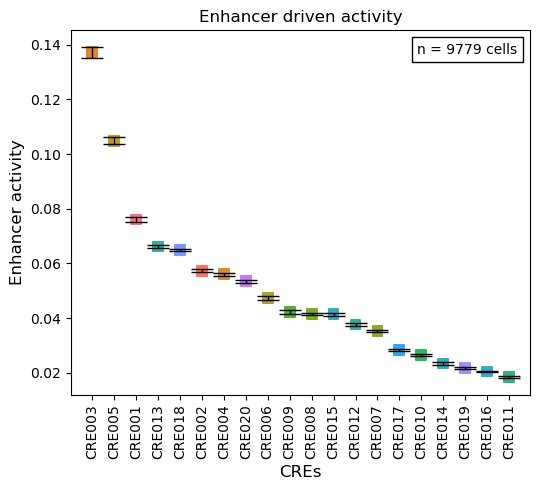

In [725]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(range(0,20), enhancer_full_sorted['score'], marker='s', c=[colors[i] for i in enhancer_full_sorted['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), enhancer_full_sorted['score'], enhancer_full_sorted['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
plt.xticks(range(0,20))
ax.set_ylabel('Enhancer activity', fontsize=12)
ax.set_title('Enhancer driven activity')
ax.set_xlabel('CREs', fontsize=12)
ax.set_xticklabels(enhancer_full_sorted['id'], rotation=90)

numcells = len(enhancer_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\activity_no_T7_normalization_240828.pdf')
plt.show()

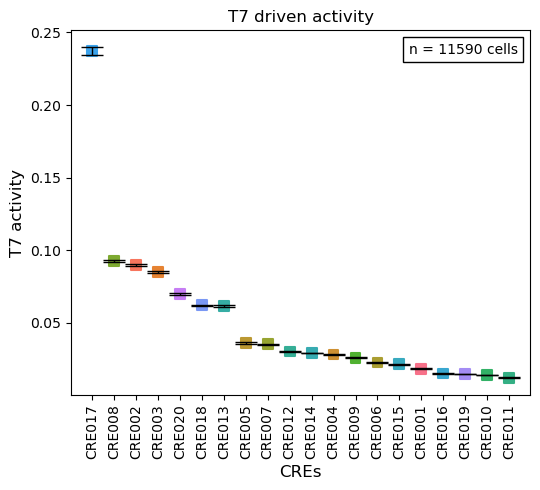

In [726]:
# Plot the T7 activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(range(0,20), T7_full_sorted['score'], marker='s', c=[colors[i] for i in T7_full_sorted['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), T7_full_sorted['score'], T7_full_sorted['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
plt.xticks(range(0,20))
ax.set_ylabel('T7 activity', fontsize=12)
ax.set_title('T7 driven activity')
ax.set_xlabel('CREs', fontsize=12)
ax.set_xticklabels(T7_full_sorted['id'], rotation=90)

numcells = len(T7_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\activity_T7_240828.pdf')
plt.show()

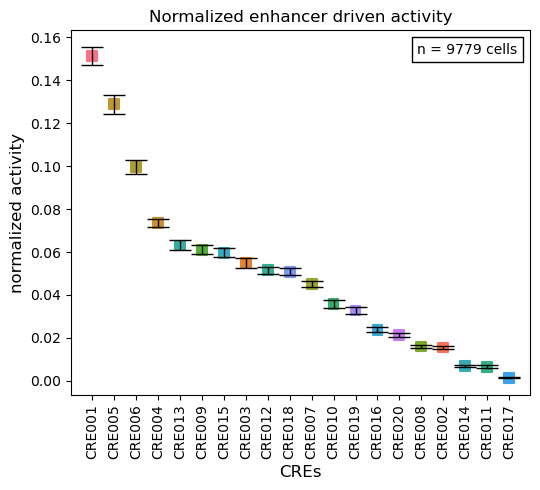

In [727]:
# Plot the norm activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(range(0,20), norm_full_sorted['score'], marker='s', c=[colors[i] for i in norm_full_sorted['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), norm_full_sorted['score'], norm_full_sorted['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
plt.xticks(range(0,20))
ax.set_ylabel('normalized activity', fontsize=12)
ax.set_title('Normalized enhancer driven activity')
ax.set_xlabel('CREs', fontsize=12)
ax.set_xticklabels(norm_full_sorted['id'], rotation=90)

numcells = len(merged2)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\activity_normalized_240828.pdf')
plt.show()

### Plot correlations between activity scores or raw counts

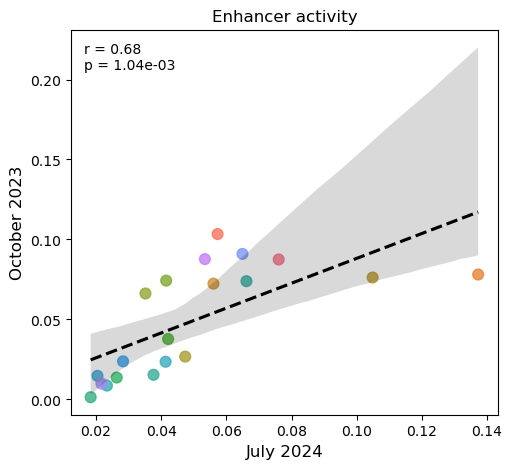

In [733]:
# plot the correlation

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = enhancer_full['score']
y = old_full['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in enhancer_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('October 2023', fontsize=12)
ax.set_xlabel('July 2024', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_activity_old_new_pearson_corr_240828.pdf')
plt.show()

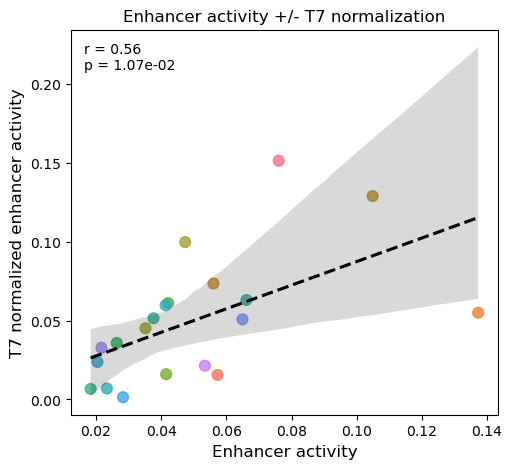

In [735]:
# plot the correlation

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = enhancer_full['score']
y = norm_full['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in enhancer_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('T7 normalized enhancer activity', fontsize=12)
ax.set_xlabel('Enhancer activity', fontsize=12)
ax.set_title('Enhancer activity +/- T7 normalization')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_activity_T7_norm_corr_240828.pdf')
plt.show()

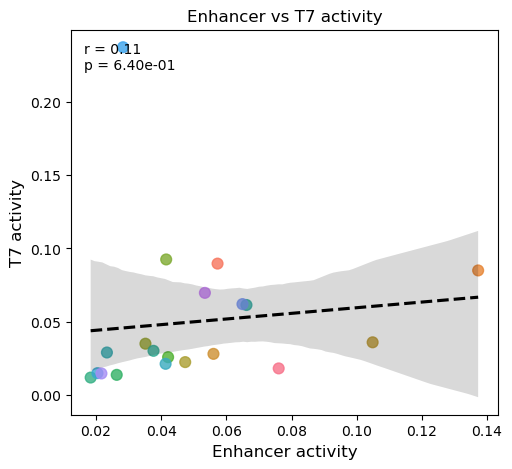

In [737]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = enhancer_full['score']
y = T7_full['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in enhancer_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('T7 activity', fontsize=12)
ax.set_xlabel('Enhancer activity', fontsize=12)
ax.set_title('Enhancer vs T7 activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_vs_T7_activity_corr_240828.pdf')
plt.show()

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_40032\3399889487.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y = (old_cbg.groupby('fov').mean()).mean()[1:21]


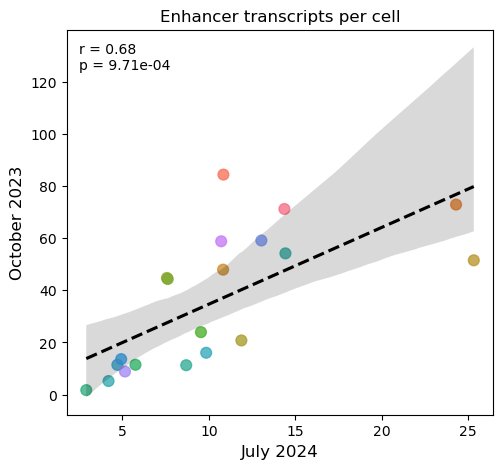

In [764]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = (enhancer_cbg.groupby('fov').mean()).mean()[1:21]
y = (old_cbg.groupby('fov').mean()).mean()[1:21]

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in enhancer_cbg.columns[1:21]], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('October 2023', fontsize=12)
ax.set_xlabel('July 2024', fontsize=12)
ax.set_title('Enhancer transcripts per cell')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_tpc_old_new_pearson_corr_240828.pdf')
plt.show()

In [401]:
norm_full

,id,score,stderr
0,CRE001,0.094890,0.002998
1,CRE002,0.046661,0.001525
2,CRE003,0.080447,0.002675
3,CRE004,0.039711,0.001206
4,CRE005,0.464203,0.007798
5,CRE006,0.022706,0.001537
6,CRE007,0.011806,0.000576
7,CRE008,0.029915,0.001176
8,CRE009,0.019007,0.001047
9,CRE010,0.007388,0.000565


In [411]:
no_outlier = [False if i == 'CRE005' else True for i in norm_full['id']]

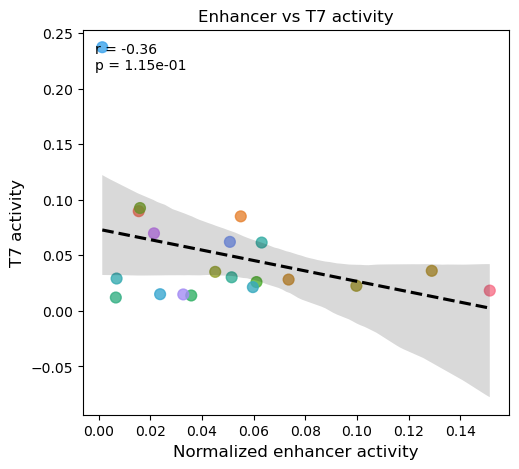

In [740]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = norm_full['score']
y = T7_full['score']

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in norm_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('T7 activity', fontsize=12)
ax.set_xlabel('Normalized enhancer activity', fontsize=12)
ax.set_title('Enhancer vs T7 activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\norm_enhancer_vs_T7_activity_corr_240828.pdf')
plt.show()

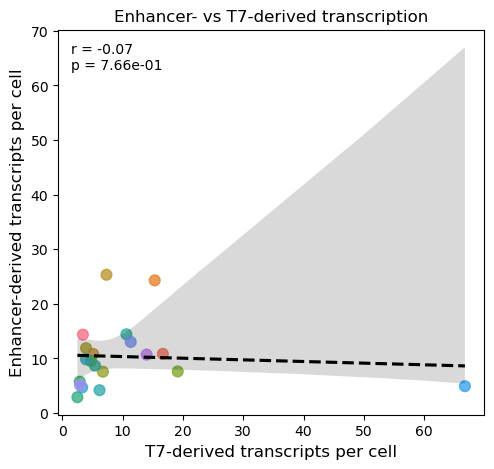

In [741]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

T7 = T7_cbg.groupby('fov').mean()
T7_means = T7.mean(axis=0)

CRE = enhancer_cbg.groupby('fov').mean()
CRE_means = CRE.mean(axis=0)

x =T7_means[1:21]
y = CRE_means[1:21]

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in norm_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('Enhancer-derived transcripts per cell', fontsize=12)
ax.set_xlabel('T7-derived transcripts per cell', fontsize=12)
ax.set_title('Enhancer- vs T7-derived transcription')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_vs_T7_tpc_corr_240828.pdf')
plt.show()

### Plot the raw T7 and enhancer (+/- normalization) counts per cell (per FOV)

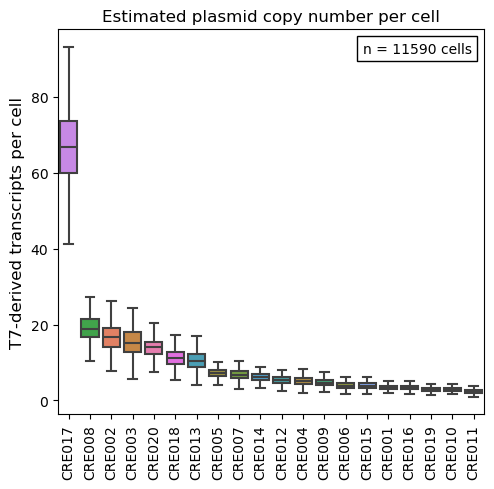

In [743]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = T7_cbg.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([T7_cbg.groupby('fov')[i].mean() for i in T7_cbg.columns[1:-2]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
            order=sort_order)
plt.xticks(np.arange(20), sort_order, rotation=90);
ax.set_ylabel('T7-derived transcripts per cell', fontsize=12)
ax.set_title('Estimated plasmid copy number per cell')

numcells = len(T7_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\T7_tpc_240828.pdf')
plt.show()

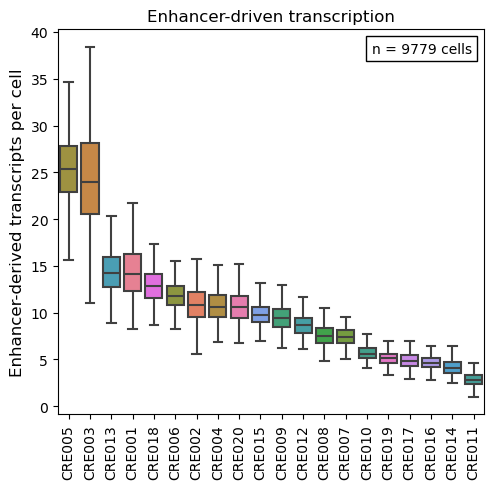

In [745]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = enhancer_cbg.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([enhancer_cbg.groupby('fov')[i].mean() for i in enhancer_cbg.columns[1:-2]],
           flierprops={"marker": "d", 'mfc' : 'gray'}, showfliers=False, linewidth=1.5,
           order=sort_order)
plt.xticks(np.arange(20), sort_order, rotation=90);
ax.set_ylabel('Enhancer-derived transcripts per cell', fontsize=12)
ax.set_title('Enhancer-driven transcription')

numcells = len(enhancer_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\enhancer_tpc_240828.pdf')
plt.show()

In [749]:
old_cbg['fov'] = pd.cut(old_cbg.masks.astype(int), bins = np.arange(0, 185)*1000, right=False)

In [187]:
norm_cbg['fov'] = pd.cut(enhancer_cbg.index.astype(int), bins = np.linspace(0, 43000, 44), right=False)

In [447]:
merged2

,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,...,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020,total transcripts,masks,fov
0,0.0,0.000000,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,2.000000,5.000000,1,"[0, 1000)"
1,0.0,0.243243,0.20,0.500,14.857143,0.500000,0.153846,0.108696,0.000000,1.000000,...,0.000000,0.333333,0.000000,0.046053,0.080,0.000000,0.166667,21.683604,10,"[0, 1000)"
2,0.0,0.000000,0.25,0.000,0.000000,0.000000,0.000000,0.600000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000,0.000000,1.333333,3.183333,11,"[0, 1000)"
3,2.2,0.250000,0.50,0.000,9.000000,1.000000,0.300000,0.125000,1.333333,0.000000,...,0.285714,0.285714,0.666667,0.042105,0.125,0.000000,0.277778,18.377026,12,"[0, 1000)"
4,1.6,0.208955,0.30,1.125,13.230769,0.437500,0.250000,0.063291,0.727273,0.500000,...,0.312500,0.400000,0.750000,0.013937,0.100,0.285714,0.106061,25.038660,13,"[0, 1000)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9569,0.0,1.166667,1.00,4.000,19.250000,0.000000,0.500000,0.500000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.600,0.000000,1.000000,31.516667,224057,"[9000, 10000)"
9570,2.0,1.125000,1.20,1.000,23.750000,6.000000,2.000000,0.266667,2.000000,2.000000,...,0.600000,2.000000,2.000000,0.041667,1.000,3.000000,1.000000,56.583333,224058,"[9000, 10000)"
9571,1.2,4.000000,0.75,2.000,6.785714,2.166667,2.250000,0.916667,0.750000,1.600000,...,1.333333,1.833333,2.000000,0.116279,1.500,1.285714,1.538462,36.359503,224060,"[9000, 10000)"
9572,0.0,1.000000,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000,3.000000,0.285714,5.285714,224062,"[9000, 10000)"


C:\Users\zgibbs\AppData\Local\Temp\ipykernel_40032\4035226.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = merged2.groupby('fov').mean()
C:\Users\zgibbs\AppData\Local\Temp\ipykernel_40032\4035226.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([merged2.groupby('fov')[i].mean() for i in merged2.columns[:-3]],


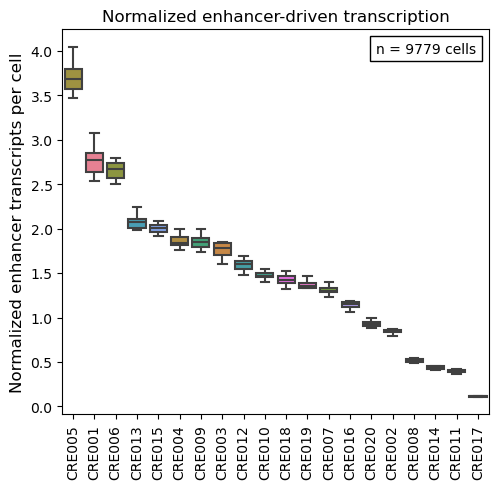

In [747]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

x = merged2.groupby('fov').mean()
sort_order = x.mean(axis=0).sort_values(ascending=False).index[2:]

fig, ax = plt.subplots(figsize=(5.5,5))
sns.boxplot([merged2.groupby('fov')[i].mean() for i in merged2.columns[:-3]],
                linewidth=1.5, showfliers=False, order=sort_order)
plt.xticks(np.arange(20), sort_order, rotation=90);
ax.set_ylabel('Normalized enhancer transcripts per cell', fontsize=12)
ax.set_title('Normalized enhancer-driven transcription')

numcells = len(merged2)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\normalized_enhancer_tpc_240828.pdf')
plt.show()

#### Plot the correlation/relationship between STARR-FISH and STARR-seq data

In [473]:
import pandas as pd

HCT116_oligos = pd.read_csv(r'C:\Users\zgibbs\cellpose\HCT116_activating_oligo.csv')

HCT116_oligos

,chr,start,end,lfc,padj
0,chr15,80003305.0,80003495.0,5.601402,3.980000e-124
1,chr15,80003185.0,80003375.0,5.445969,2.070000e-119
2,chr1,244735538.0,244735728.0,5.140302,9.600000e-111
3,chr21,33367286.0,33367476.0,5.099388,1.110000e-109
4,chr22,49384139.0,49384329.0,5.031316,1.690000e-103
...,...,...,...,...,...
1101,YFL009W_196_385,NaN,NaN,0.006862,9.663627e-01
1102,YNL186W_1584_1773,NaN,NaN,0.002139,9.842529e-01
1103,YDR490C_1052_1241,NaN,NaN,0.001636,9.862793e-01
1104,YLR138W_2138_2327,NaN,NaN,-0.001606,9.969921e-01


In [474]:
STARRseq = pd.read_csv(r'C:\Users\zgibbs\cellpose\RNAvsDNA.edgeR.csv')
STARRseq

,genes,genes.1,logFC,logCPM,LR,PValue,FDR
0,chr15:80003305-80003495,chr15:80003305-80003495,5.601385,10.262335,931.208886,1.610000e-204,1.200000e-200
1,chr15:80003185-80003375,chr15:80003185-80003375,5.445952,9.878489,1306.822523,3.720000e-286,5.530000e-282
2,chr1:244735538-244735728,chr1:244735538-244735728,5.140283,10.398185,926.936868,1.370000e-203,6.770000e-200
3,chr21:33367286-33367476,chr21:33367286-33367476,5.099376,10.493151,765.505615,1.710000e-168,4.220000e-165
4,chr22:49384139-49384329,chr22:49384139-49384329,5.032509,7.528481,73.439476,1.040000e-17,1.200000e-16
...,...,...,...,...,...,...,...
14847,chr1:161103553-161103743,chr1:161103553-161103743,-6.555657,4.820906,305.059169,2.600000e-68,2.740000e-66
14848,chr3:186999245-186999435,chr3:186999245-186999435,-6.568334,5.249774,685.633001,3.980000e-151,6.570000e-148
14849,chr2:29107347-29107537,chr2:29107347-29107537,-6.679742,4.950180,563.129284,1.750000e-124,9.650000e-122
14850,chr14:102084508-102084698,chr14:102084508-102084698,-6.838318,5.246542,627.747588,1.540000e-138,1.270000e-135


In [475]:
# Indices of 20 test CREs for STARR-FISH from STARR-seq data
test_CREs = [0,11,4,7,9,137,186,323,515,642,1100,1086,1078,1073,1093,1101,1102,1103,1104,1105]

In [476]:
STARRseq['logFC'].loc[test_CREs]

0       5.601385
11      4.373055
4       5.032509
7       4.685353
9       4.493735
137     2.122961
186     1.903971
323     1.588704
515     1.326764
642     1.219671
1100    0.973408
1086    0.983154
1078    0.986207
1073    0.986843
1093    0.978426
1101    0.972873
1102    0.972759
1103    0.972564
1104    0.971994
1105    0.971080
Name: logFC, dtype: float64

In [78]:
log2_FC.iloc[:,1:21].mean()

CRE001    1.901057
CRE002    2.950479
CRE003    2.937164
CRE004    2.230428
CRE005    2.040150
CRE006    1.369877
CRE007    2.379075
CRE008    2.672721
CRE009    1.559800
CRE010    2.006306
CRE011    1.086325
CRE012    1.657502
CRE013    3.017521
CRE014    1.321665
CRE015    1.420879
CRE016    1.844469
CRE017    3.547758
CRE018    2.540390
CRE019    1.877166
CRE020    2.847666
dtype: float64

In [ ]:
SF_FC =

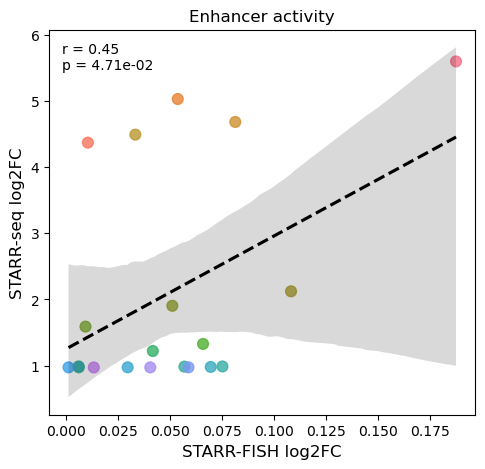

In [477]:
# plot the correlation between replicates

import seaborn as sns
from scipy import stats

fig, ax = plt.subplots(figsize=(5.5,5))

x = norm_full['score']
y = STARRseq['logFC'].loc[test_CREs]

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            scatter_kws={'color' : [colors[i] for i in norm_full['id']], 's' : 60},
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_ylabel('STARR-seq log2FC', fontsize=12)
ax.set_xlabel('STARR-FISH log2FC', fontsize=12)
ax.set_title('Enhancer activity')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_vs_rep2_activity_240607.pdf')
plt.show()

In [ ]:
# Plot the enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(5.5,5))

ax.scatter(range(0,20), d_full_sorted_norm['score'], marker='s', c=[colors[i] for i in d_full_sorted_norm['id']], s=50, lw=1.5)
ax.errorbar(range(0,20), d_full_sorted_norm['score'], d_full_sorted_norm['stderr'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
plt.xticks(range(0,20))
ax.set_ylabel('Enhancer activity', fontsize=12)
ax.set_title('20CRE (with T7 normalization)')
ax.set_xlabel('CREs', fontsize=12)
ax.set_xticklabels(d_full_sorted_norm['id'], rotation=90)

numcells = len(norm_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

plt.tight_layout()
# plt.savefig('/home/zgibbs/STARR-FISH/HCT116_20CRE_analysis/figures/rep1_activity_240607.pdf')
plt.show()

TypeError: 'Index' object is not callable

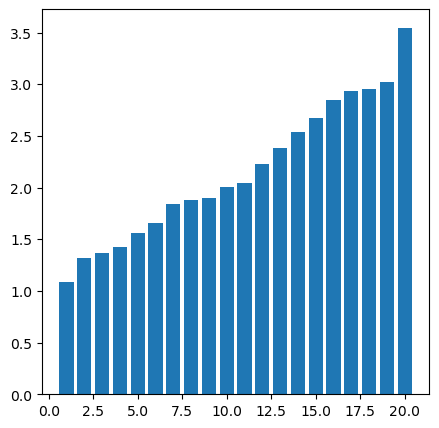

In [90]:
fig, ax = plt.subplots(figsize=(5,5))

ax.bar(np.arange(1,21), log2_FC.iloc[:,1:21].mean().sort_values())
ax.set_xticklabels(log2_FC.columns[i]lam

### Try sampling smaller number of cells for linear regression: how many cells needed to measure enhancer activity?

In [19]:
df100

,0,1,2,3,4,5,6,7,8,9,stdev,avg,CV
CRE015,0.002665,0.002820,0.002628,0.003168,0.005168,0.005335,0.002224,0.002880,0.004714,0.003513,0.001138,0.003511,0.324210
CRE018,0.009768,0.010057,0.011051,0.008387,0.008486,0.008056,0.008778,0.008139,0.010508,0.009615,0.001058,0.009285,0.113969
CRE021,0.000084,0.000152,0.000151,0.000082,0.000070,0.000110,0.000058,0.000085,0.000028,0.000042,0.000042,0.000086,0.482207
CRE024,0.000407,0.000756,0.000494,0.000586,0.000707,0.000769,0.000849,0.000611,0.000483,0.000680,0.000143,0.000634,0.225332
CRE027,0.001674,0.001425,0.001573,0.001307,0.001190,0.000887,0.001684,0.002239,0.001412,0.001428,0.000356,0.001482,0.240122
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRE287,0.000041,0.000015,0.000016,0.000053,0.000286,0.000033,-0.000015,0.000038,0.000153,0.000024,0.000089,0.000064,1.394299
CRE290,0.000078,0.000183,0.000234,0.000250,0.000114,0.000139,0.000200,0.000223,0.000131,0.000156,0.000056,0.000171,0.330293
CRE293,0.000031,0.000068,0.000074,0.000076,0.000043,0.000021,0.000031,0.000027,0.000026,0.000024,0.000022,0.000042,0.516935
CRE296,0.020462,0.014629,0.015231,0.015666,0.015416,0.015718,0.020682,0.016609,0.014787,0.013927,0.002357,0.016313,0.144482


In [305]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=100)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df100 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df100['stdev'] = df100.std(axis=1)
df100['avg'] = df100[df100.columns[:10]].mean(axis=1)
df100['CV'] = df100.stdev/df100.avg
d100 = df100.sort_values('avg', axis=0, ascending=False)

In [306]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=50)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df50 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df50['stdev'] = df50.std(axis=1)
df50['avg'] = df50[df50.columns[:10]].mean(axis=1)
df50['CV'] = df50.stdev/df50.avg
d50 = df50.sort_values('avg', axis=0, ascending=False)

In [307]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=250)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df250 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df250['stdev'] = df250.std(axis=1)
df250['avg'] = df250[df250.columns[:10]].mean(axis=1)
df250['CV'] = df250.stdev/df250.avg
d250 = df250.sort_values('avg', axis=0, ascending=False)

In [300]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=500)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df500 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df500['stdev'] = df500.std(axis=1)
df500['avg'] = df500[df500.columns[:10]].mean(axis=1)
df500['CV'] = df500.stdev/df500.avg
d500 = df500.sort_values('avg', axis=0, ascending=False)

In [301]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=1000)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df1000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df1000['stdev'] = df1000.std(axis=1)
df1000['avg'] = df1000[df1000.columns[:10]].mean(axis=1)
df1000['CV'] = df1000.stdev/df1000.avg
d1000 = df1000.sort_values('avg', axis=0, ascending=False)

In [302]:
from scipy import stats

# set number of sampled dataframes to create
num_samples = 10

# generate empty list for appending new sampled dataframes
sampled_dfs = []

# repeatedly sample the dataframe for slopes and append to the list
for _ in range(num_samples):
    pseudo_rep = merged2.sample(n=2000)

    pseudo_res = []

    for cre in pseudo_rep.columns[:20]:
        res = stats.linregress(pseudo_rep['total transcripts'], pseudo_rep[cre])
        pseudo_res.append(res)
        
    y = [pseudo_res[i].slope for i in range(20)]
    d = pd.DataFrame(list(zip(y)), columns = ['score'], index=pseudo_rep.columns[:20])
    sampled_dfs.append(d)

# combine sampled data into one new dataframe and calculate standard deviation across samplings
df2000 = pd.concat(sampled_dfs, ignore_index=True, axis=1)
df2000['stdev'] = df2000.std(axis=1)
df2000['avg'] = df2000[df2000.columns[:10]].mean(axis=1)
df2000['CV'] = df2000.stdev/df2000.avg
d2000 = df2000.sort_values('avg', axis=0, ascending=False)

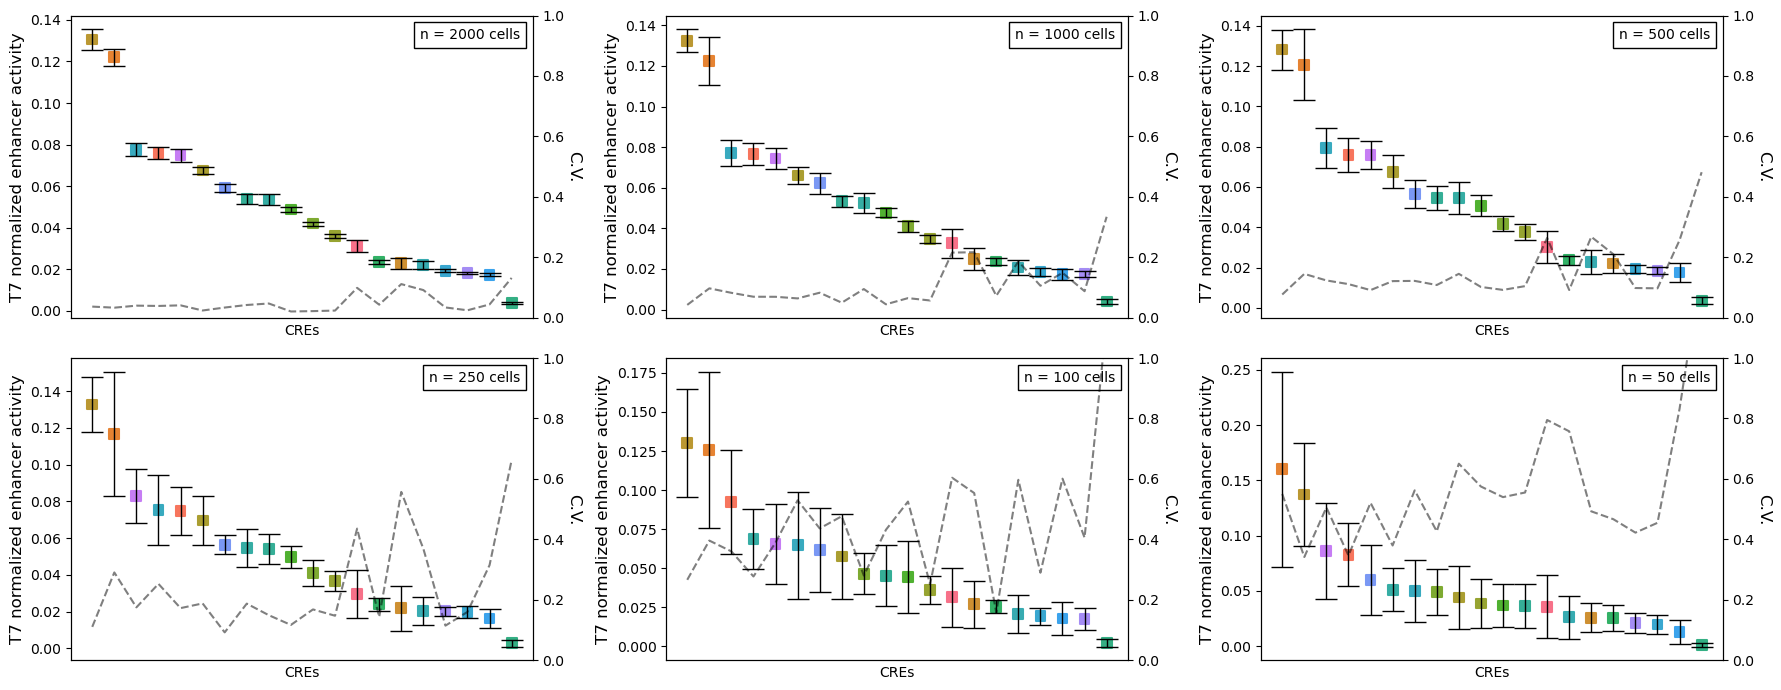

In [309]:
# Plot the T7 normalized enhancer activity scores in a descending order

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

fig, axs = plt.subplots(2, 3, figsize=(18,7))

axs[0,0].scatter(range(0,20), d2000['avg'], marker='s', c=[colors[i] for i in d2000.index], s=50, lw=1.5)
axs[0,0].errorbar(range(0,20), d2000['avg'], d2000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,0].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,0].set_xlabel('CREs')
axs[0,0].set_xticks([])
# axs[0,0].set_title('2500 cells')

ax1 = axs[0, 0].twinx()
ax1.plot(range(0,20), d2000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax1.set_ylim(0,1)
ax1.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,1].scatter(range(0,20), d1000['avg'], marker='s', c=[colors[i] for i in d1000.index], s=50, lw=1.5)
axs[0,1].errorbar(range(0,20), d1000['avg'], d1000['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,1].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,1].set_xlabel('CREs')
axs[0,1].set_xticks([])
# axs[1,0].set_title('1000 cells')

ax2 = axs[0,1].twinx()
ax2.plot(range(0,20), d1000['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax2.set_ylim(0,1)
ax2.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[0,2].scatter(range(0,20), d500['avg'], marker='s', c=[colors[i] for i in d500.index], s=50, lw=1.5)
axs[0,2].errorbar(range(0,20), d500['avg'], d500['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[0,2].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[0,2].set_xlabel('CREs')
axs[0,2].set_xticks([])
# axs[2,0].set_title('500 cells')

ax3 = axs[0,2].twinx()
ax3.plot(range(0,20), d500['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax3.set_ylim(0,1)
ax3.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,0].scatter(range(0,20), d250['avg'], marker='s', c=[colors[i] for i in d250.index], s=50, lw=1.5)
axs[1,0].errorbar(range(0,20), d250['avg'], d250['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,0].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,0].set_xlabel('CREs')
axs[1,0].set_xticks([])
# axs[0,1].set_title('250 cells')

ax4 = axs[1,0].twinx()
ax4.plot(range(0,20), d250['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax4.set_ylim(0,1)
ax4.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,1].scatter(range(0,20), d100['avg'], marker='s', c=[colors[i] for i in d100.index], s=50, lw=1.5)
axs[1,1].errorbar(range(0,20), d100['avg'], d100['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,1].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,1].set_xlabel('CREs')
axs[1,1].set_xticks([])
# axs[1,1].set_title('100 cells')

ax5 = axs[1, 1].twinx()
ax5.plot(range(0,20), d100['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax5.set_ylim(0,1)
ax5.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

axs[1,2].scatter(range(0,20), d50['avg'], marker='s', c=[colors[i] for i in d50.index], s=50, lw=1.5)
axs[1,2].errorbar(range(0,20), d50['avg'], d50['stdev'], linestyle='', linewidth=1, capsize=8, mew=1, ecolor='k')
axs[1,2].set_ylabel('T7 normalized enhancer activity', fontsize=12)
axs[1,2].set_xlabel('CREs')
axs[1,2].set_xticks([])
# axs[2,1].set_title('50 cells')

ax6 = axs[1,2].twinx()
ax6.plot(range(0,20), d50['CV'], lw=1.5, c='k', linestyle='--', alpha=0.5, zorder=1)
ax6.set_ylim(0,1)
ax6.set_ylabel('C.V.', fontsize=12, rotation=270, labelpad=12)

anchored_text1 = AnchoredText(f"n = 2000 cells", loc=1)
axs[0,0].add_artist(anchored_text1)
anchored_text2 = AnchoredText(f"n = 1000 cells", loc=1)
axs[0,1].add_artist(anchored_text2)
anchored_text3 = AnchoredText(f"n = 500 cells", loc=1)
axs[0,2].add_artist(anchored_text3)

anchored_text4 = AnchoredText(f"n = 250 cells", loc=1)
axs[1,0].add_artist(anchored_text4)
anchored_text5 = AnchoredText(f"n = 100 cells", loc=1)
axs[1,1].add_artist(anchored_text5)
anchored_text6 = AnchoredText(f"n = 50 cells", loc=1)
axs[1,2].add_artist(anchored_text6)

plt.tight_layout()
# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\downsampling_T7_normalized_240806.pdf')
plt.show()